## This is the final model that gives the best results for our dataset

It still has some problems but we should be able to analyze them and tie it into the content from Phase A.

In [33]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

print("all imports loaded!!")

all imports loaded!!


In [34]:
# load in data from aggregated data folder
df_all_data = pd.read_csv("../Aggregated_Data/all_data_median_per_beef.csv")
df_all_data["observation_date"] = df_all_data["observation_date"].apply(pd.to_datetime)
df_all_data = df_all_data.query("observation_date.dt.year >= 1998")
df_all_data = df_all_data.dropna()
df_all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167 entries, 251 to 421
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   observation_date                        167 non-null    datetime64[ns]
 1   med_price_beef                          167 non-null    object        
 2   avg_price_chicken                       167 non-null    float64       
 3   avg_price_ham                           167 non-null    float64       
 4   avg_price_pork                          167 non-null    float64       
 5   corn_futures_settlement_price           167 non-null    float64       
 6   corn_futures_CVol                       167 non-null    float64       
 7   index_dec_2011                          167 non-null    float64       
 8   live_cattle_futures_settlement_price    167 non-null    float64       
 9   live_cattle_futures_CVol                167 non-null    f

In [35]:
# aggregating the competing meat prices into a single index (based on results of the correlation matrix
df_all_data["meat_price_index"] = df_all_data[["avg_price_chicken", "avg_price_ham", "avg_price_pork"]].mean(axis=1)

# adding a beef lag variable to control for the autocorrelation (helps us look at how last month's beef pricing impacts this month's
df_all_data['beef_lag'] = df_all_data["med_price_beef"].shift(1)
df_all_data = df_all_data.dropna()

# looking at the gap between this in the beef industry
df_all_data["cattle_spread"] = (df_all_data["feeder_cattle_futures_settlement_price"] - df_all_data["live_cattle_futures_settlement_price"])

# fixing some type issues
df_all_data["med_price_beef"] = df_all_data["med_price_beef"].apply(pd.to_numeric, errors="coerce")
df_all_data["beef_lag"] = df_all_data["beef_lag"].apply(pd.to_numeric, errors="coerce")


In [36]:
# First just running the model without the log adjustment
# y variable
y = df_all_data['med_price_beef'].copy()

# X variables
X = df_all_data[["beef_lag", "meat_price_index", "cattle_spread", "ulsd_price", "wpi"]]
X = sm.add_constant(X)

raw = sm.OLS(y, X).fit()
print(raw.summary())

                            OLS Regression Results                            
Dep. Variable:         med_price_beef   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     1628.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          3.38e-135
Time:                        00:29:00   Log-Likelihood:                 85.228
No. Observations:                 166   AIC:                            -158.5
Df Residuals:                     160   BIC:                            -139.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.4418      0.113  

### Results of Note From this Run:
- $R^{2}$ and ${R_{adj}}^{2}$ look good ==> 0.98 and 0.979 respectively
- All features are significant
- Durbin-Watson looks good ==> 2.034 (very close to 2)
- Condition number has been controlled ==> 95.5 (earlier models had crazy ones around 3E6
- Omnibous and JB show that there are some crazy skews going on with the data

### having claude do some quick plots for this first model


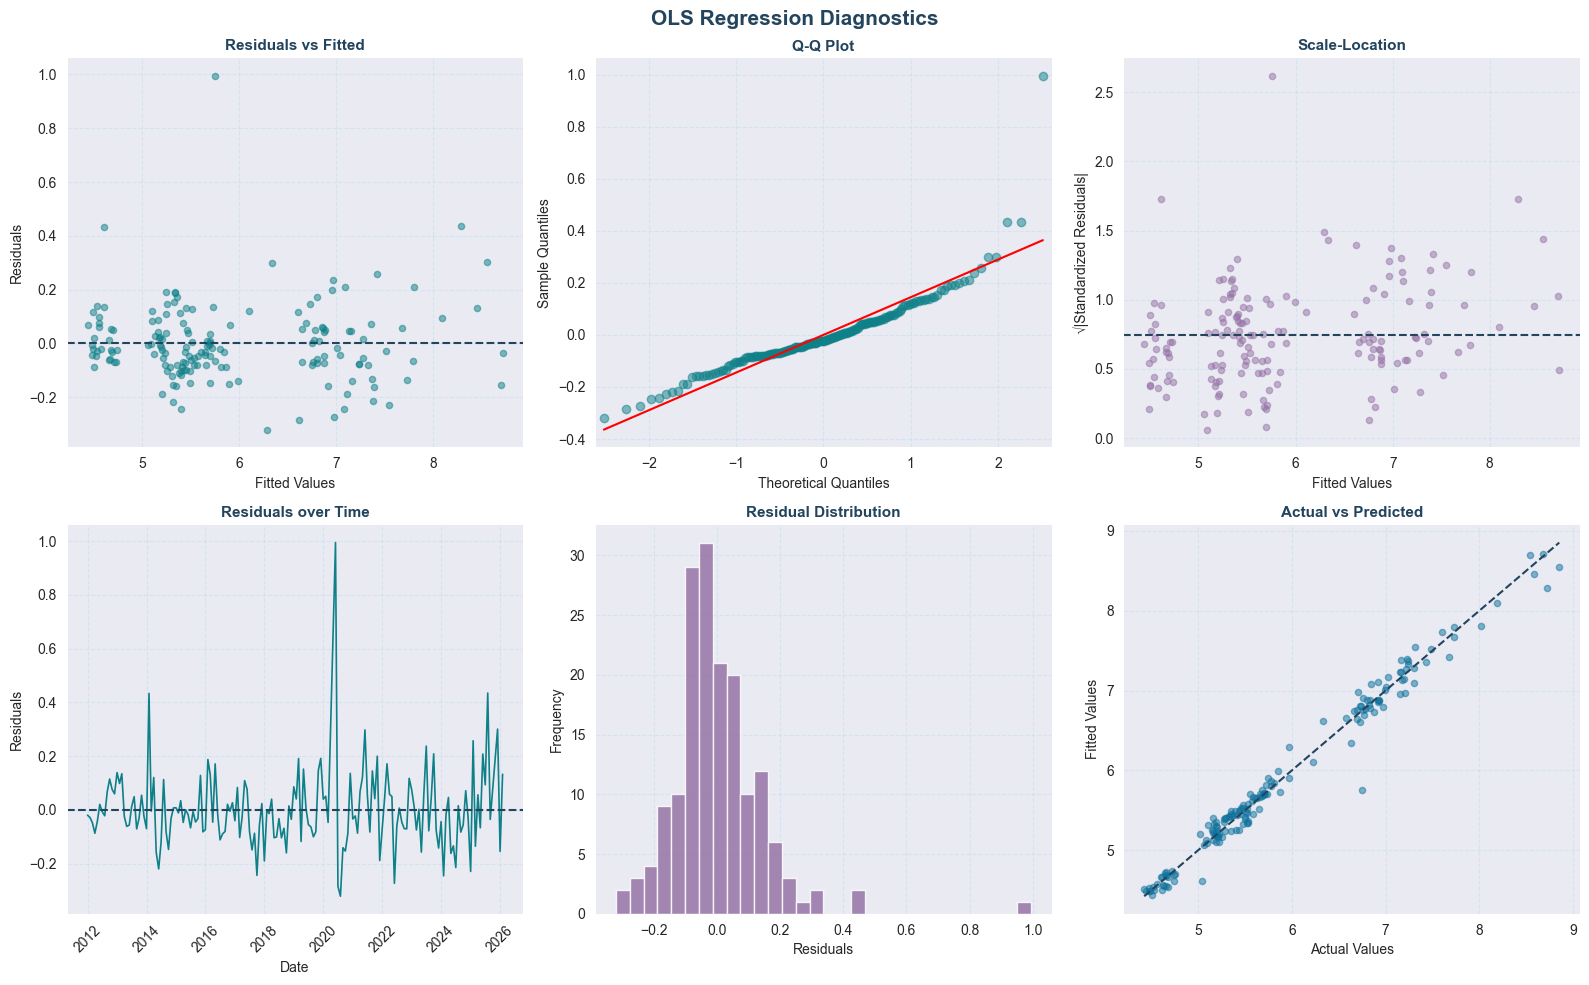


Durbin-Watson:          2.0322
Shapiro-Wilk:           W=0.8616, p=0.000000 → NOT normal
Breusch-Pagan (hetero): stat=10.8868, p=0.053671 → Homoskedastic


In [37]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot

fitted    = raw.fittedvalues
residuals = raw.resid
std_resid = residuals / residuals.std()

# align dates and y values to match residuals length
n = len(residuals)
dates  = df_all_data["observation_date"].iloc[-n:].reset_index(drop=True)
y_aligned = y.iloc[-n:].reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor="white")
fig.suptitle("OLS Regression Diagnostics", fontsize=15, fontweight="bold", color="#23445d")

# ── 1. Residuals vs Fitted ────────────────────────────────────────────────────
axes[0,0].scatter(fitted, residuals, color="#0e8088", alpha=0.5, s=20)
axes[0,0].axhline(0, color="#23445d", linestyle="--", linewidth=1.5)
axes[0,0].set_xlabel("Fitted Values", fontsize=10)
axes[0,0].set_ylabel("Residuals", fontsize=10)
axes[0,0].set_title("Residuals vs Fitted", fontsize=11, fontweight="bold", color="#23445d")
axes[0,0].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,0].spines[["top","right"]].set_visible(False)

# ── 2. Q-Q Plot ───────────────────────────────────────────────────────────────
qqplot(residuals, line="s", ax=axes[0,1], markerfacecolor="#0e8088",
       markeredgecolor="#0e8088", alpha=0.5)
axes[0,1].set_title("Q-Q Plot", fontsize=11, fontweight="bold", color="#23445d")
axes[0,1].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,1].spines[["top","right"]].set_visible(False)

# ── 3. Scale-Location ─────────────────────────────────────────────────────────
axes[0,2].scatter(fitted, np.sqrt(np.abs(std_resid)), color="#9673a6", alpha=0.5, s=20)
axes[0,2].axhline(np.sqrt(np.abs(std_resid)).mean(), color="#23445d", linestyle="--", linewidth=1.5)
axes[0,2].set_xlabel("Fitted Values", fontsize=10)
axes[0,2].set_ylabel("√|Standardized Residuals|", fontsize=10)
axes[0,2].set_title("Scale-Location", fontsize=11, fontweight="bold", color="#23445d")
axes[0,2].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,2].spines[["top","right"]].set_visible(False)

# ── 4. Residuals over time ────────────────────────────────────────────────────
axes[1,0].plot(dates, residuals.values, color="#0e8088", linewidth=1.2)
axes[1,0].axhline(0, color="#23445d", linestyle="--", linewidth=1.5)
axes[1,0].set_xlabel("Date", fontsize=10)
axes[1,0].set_ylabel("Residuals", fontsize=10)
axes[1,0].set_title("Residuals over Time", fontsize=11, fontweight="bold", color="#23445d")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,0].spines[["top","right"]].set_visible(False)

# ── 5. Residual histogram ─────────────────────────────────────────────────────
axes[1,1].hist(residuals, bins=30, color="#9673a6", edgecolor="white", alpha=0.85)
axes[1,1].set_xlabel("Residuals", fontsize=10)
axes[1,1].set_ylabel("Frequency", fontsize=10)
axes[1,1].set_title("Residual Distribution", fontsize=11, fontweight="bold", color="#23445d")
axes[1,1].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,1].spines[["top","right"]].set_visible(False)

# ── 6. Actual vs Predicted ────────────────────────────────────────────────────
axes[1,2].scatter(y_aligned, fitted, color="#10739e", alpha=0.5, s=20)
axes[1,2].plot([y_aligned.min(), y_aligned.max()],
               [y_aligned.min(), y_aligned.max()],
               color="#23445d", linestyle="--", linewidth=1.5)
axes[1,2].set_xlabel("Actual Values", fontsize=10)
axes[1,2].set_ylabel("Fitted Values", fontsize=10)
axes[1,2].set_title("Actual vs Predicted", fontsize=11, fontweight="bold", color="#23445d")
axes[1,2].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
dw       = durbin_watson(residuals)
sw_stat, sw_p = stats.shapiro(residuals)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X)

print(f"\nDurbin-Watson:          {dw:.4f}")
print(f"Shapiro-Wilk:           W={sw_stat:.4f}, p={sw_p:.6f} → {'NOT normal' if sw_p < 0.05 else 'normal'}")
print(f"Breusch-Pagan (hetero): stat={bp_stat:.4f}, p={bp_p:.6f} → {'Heteroskedasticity detected' if bp_p < 0.05 else 'Homoskedastic'}")

## Applying the log scaling to the model to compare the output

In [38]:
df_all_data

,observation_date,med_price_beef,avg_price_chicken,avg_price_ham,avg_price_pork,corn_futures_settlement_price,corn_futures_CVol,index_dec_2011,live_cattle_futures_settlement_price,live_cattle_futures_CVol,feeder_cattle_futures_settlement_price,feeder_cattle_futures_CVol,cpi,wpi,ulsd_price,per_change_med_price_beef,meat_price_index,beef_lag,cattle_spread
252,2012-01-01,4.559,1.334,2.406,2.683,6.2450,157451.25,99.700,1.29,22779.0,1.56,3232.0,3,4.3,3.0825,0.022,2.141000,4.558,0.27
253,2012-02-01,4.513,1.356,2.376,2.627,6.4000,138652.00,98.300,1.30,31973.0,1.57,3088.0,2.9,3.5,3.2250,-1.009,2.119667,4.559,0.27
254,2012-03-01,4.479,1.372,2.442,2.652,6.5280,156888.40,98.900,1.16,40963.0,1.49,5917.0,2.6,2.8,3.3020,-0.753,2.155333,4.513,0.33
255,2012-04-01,4.424,1.401,2.462,2.662,6.2900,180245.75,99.700,1.14,32116.0,1.50,3275.0,2.3,1.8,3.2500,-1.228,2.175000,4.479,0.36
256,2012-05-01,4.447,1.347,2.576,2.609,6.0400,165994.00,102.000,1.19,29469.0,1.57,2739.0,1.7,0.7,2.9725,0.520,2.177333,4.424,0.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,2025-08-01,8.723,2.076,4.792,3.695,4.0200,172930.00,113.054,2.40,34150.0,3.65,6137.0,2.9,2.0,2.3240,6.534,3.521000,8.188,1.25
416,2025-09-01,8.680,2.061,4.785,3.825,4.2350,189908.50,113.333,2.35,25602.0,3.61,4676.0,3,3.1,2.3775,-0.493,3.557000,8.723,1.26
419,2025-12-01,8.853,2.020,4.367,3.625,4.4500,127546.00,121.954,2.32,14217.0,3.50,1967.0,2.7,2.0,2.2475,-3.478,3.337333,8.680,1.18
420,2026-01-01,8.546,2.041,4.346,3.767,4.3360,173407.00,125.511,2.37,31563.0,3.60,13260.0,2.4,0.9,2.2660,-3.468,3.384667,8.853,1.23


In [39]:
df_all_data["log_beef"] = np.log(df_all_data["med_price_beef"])
df_all_data["log_meat_index"] = np.log(df_all_data["meat_price_index"])
df_all_data["log_cattle_spread"] = np.log(df_all_data["cattle_spread"].clip(lower=0.001))
df_all_data["log_ulsd"] = np.log(df_all_data["ulsd_price"])

model_log = smf.ols("""log_beef ~ beef_lag + log_meat_index +
    log_cattle_spread + log_ulsd + wpi""", data=df_all_data).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:               log_beef   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     1600.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          1.30e-134
Time:                        00:29:03   Log-Likelihood:                 384.97
No. Observations:                 166   AIC:                            -757.9
Df Residuals:                     160   BIC:                            -739.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.8771      0.02

## Takeaways from this model
- $R^{2}$ and ${R_{adj}}^{2}$ look good ==> 0.98 and 0.979 respectively this stayed the same from last time
- all features are still significant
- Durbin-Watson had a little bit of a drop but not too far off from before or from ideal (1.879)
- cond number jumped up a little bit ==> 139
- A bit of improvement with skew but stil shows some significant skew
  - potentially due to outlier periods like recessions

### having claude do some quick plots for this model now

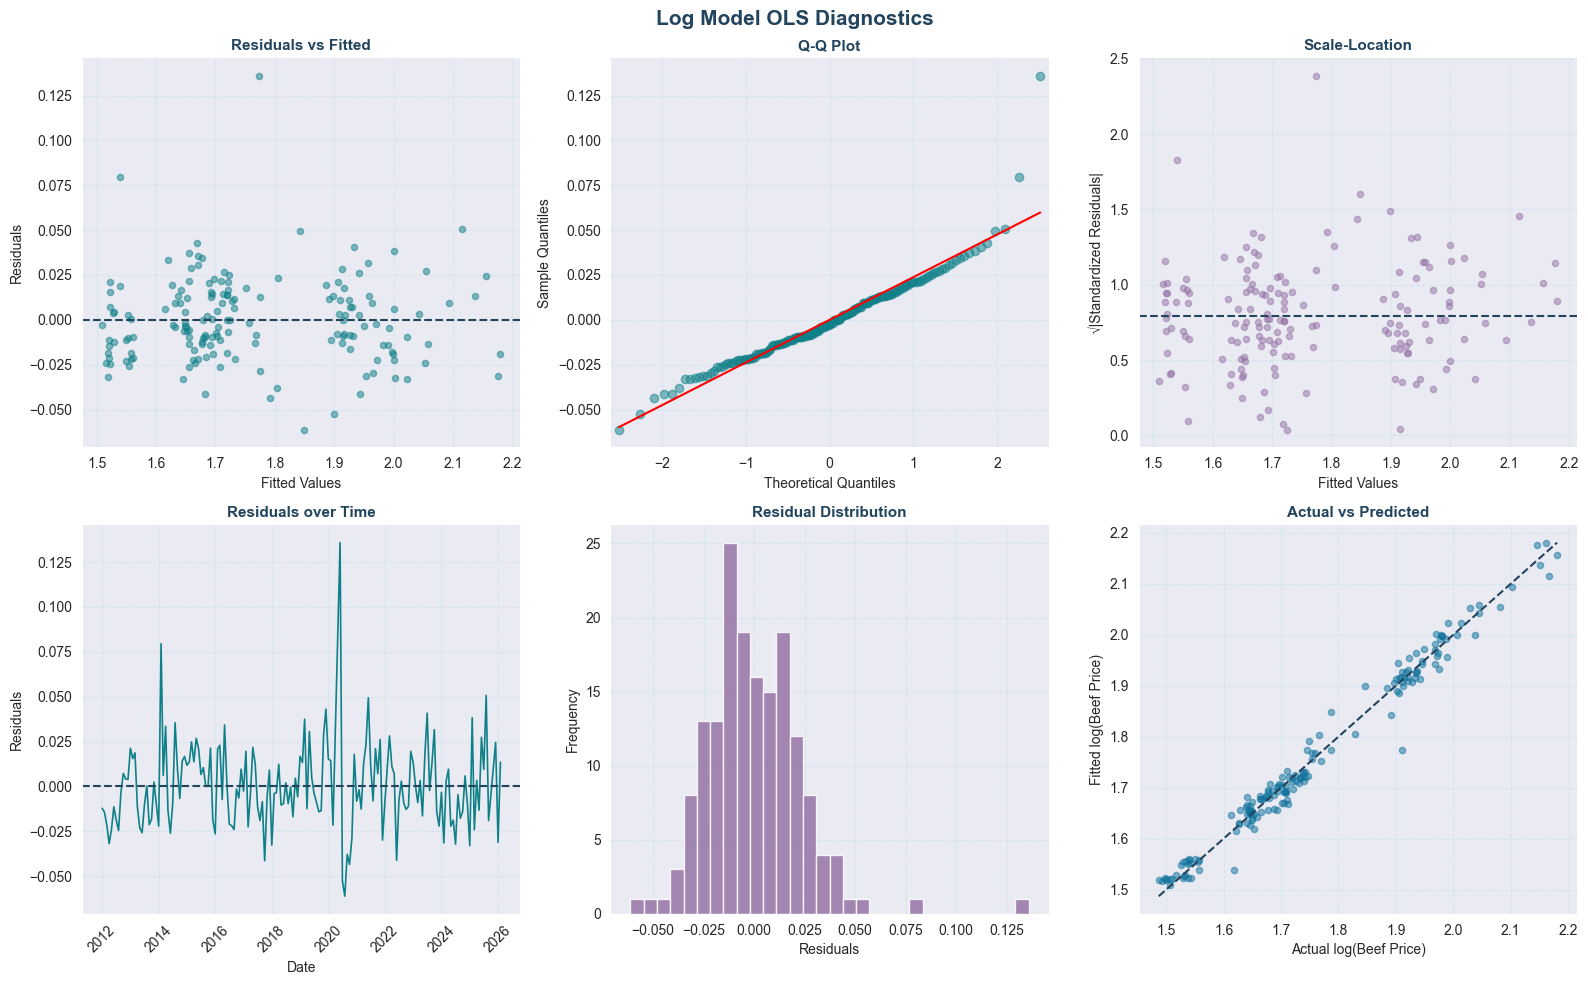


Durbin-Watson:          1.8600
Shapiro-Wilk:           W=0.9327, p=0.000001 → NOT normal
Breusch-Pagan (hetero): stat=15.1397, p=0.009782 → Heteroskedasticity detected


In [40]:
fitted    = model_log.fittedvalues
residuals = model_log.resid
std_resid = residuals / residuals.std()

# align dates and y values to match residuals length
n         = len(residuals)
dates     = df_all_data["observation_date"].iloc[-n:].reset_index(drop=True)
y_aligned = df_all_data["log_beef"].iloc[-n:].reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor="white")
fig.suptitle("Log Model OLS Diagnostics", fontsize=15, fontweight="bold", color="#23445d")

# ── 1. Residuals vs Fitted ────────────────────────────────────────────────────
axes[0,0].scatter(fitted, residuals, color="#0e8088", alpha=0.5, s=20)
axes[0,0].axhline(0, color="#23445d", linestyle="--", linewidth=1.5)
axes[0,0].set_xlabel("Fitted Values", fontsize=10)
axes[0,0].set_ylabel("Residuals", fontsize=10)
axes[0,0].set_title("Residuals vs Fitted", fontsize=11, fontweight="bold", color="#23445d")
axes[0,0].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,0].spines[["top","right"]].set_visible(False)

# ── 2. Q-Q Plot ───────────────────────────────────────────────────────────────
qqplot(residuals, line="s", ax=axes[0,1], markerfacecolor="#0e8088",
       markeredgecolor="#0e8088", alpha=0.5)
axes[0,1].set_title("Q-Q Plot", fontsize=11, fontweight="bold", color="#23445d")
axes[0,1].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,1].spines[["top","right"]].set_visible(False)

# ── 3. Scale-Location ─────────────────────────────────────────────────────────
axes[0,2].scatter(fitted, np.sqrt(np.abs(std_resid)), color="#9673a6", alpha=0.5, s=20)
axes[0,2].axhline(np.sqrt(np.abs(std_resid)).mean(), color="#23445d", linestyle="--", linewidth=1.5)
axes[0,2].set_xlabel("Fitted Values", fontsize=10)
axes[0,2].set_ylabel("√|Standardized Residuals|", fontsize=10)
axes[0,2].set_title("Scale-Location", fontsize=11, fontweight="bold", color="#23445d")
axes[0,2].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,2].spines[["top","right"]].set_visible(False)

# ── 4. Residuals over time ────────────────────────────────────────────────────
axes[1,0].plot(dates, residuals.values, color="#0e8088", linewidth=1.2)
axes[1,0].axhline(0, color="#23445d", linestyle="--", linewidth=1.5)
axes[1,0].set_xlabel("Date", fontsize=10)
axes[1,0].set_ylabel("Residuals", fontsize=10)
axes[1,0].set_title("Residuals over Time", fontsize=11, fontweight="bold", color="#23445d")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,0].spines[["top","right"]].set_visible(False)

# ── 5. Residual histogram ─────────────────────────────────────────────────────
axes[1,1].hist(residuals, bins=30, color="#9673a6", edgecolor="white", alpha=0.85)
axes[1,1].set_xlabel("Residuals", fontsize=10)
axes[1,1].set_ylabel("Frequency", fontsize=10)
axes[1,1].set_title("Residual Distribution", fontsize=11, fontweight="bold", color="#23445d")
axes[1,1].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,1].spines[["top","right"]].set_visible(False)

# ── 6. Actual vs Predicted ────────────────────────────────────────────────────
axes[1,2].scatter(y_aligned, fitted, color="#10739e", alpha=0.5, s=20)
axes[1,2].plot([y_aligned.min(), y_aligned.max()],
               [y_aligned.min(), y_aligned.max()],
               color="#23445d", linestyle="--", linewidth=1.5)
axes[1,2].set_xlabel("Actual log(Beef Price)", fontsize=10)
axes[1,2].set_ylabel("Fitted log(Beef Price)", fontsize=10)
axes[1,2].set_title("Actual vs Predicted", fontsize=11, fontweight="bold", color="#23445d")
axes[1,2].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
dw            = durbin_watson(residuals)
sw_stat, sw_p = stats.shapiro(residuals)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, model_log.model.exog)

print(f"\nDurbin-Watson:          {dw:.4f}")
print(f"Shapiro-Wilk:           W={sw_stat:.4f}, p={sw_p:.6f} → {'NOT normal' if sw_p < 0.05 else 'normal'}")
print(f"Breusch-Pagan (hetero): stat={bp_stat:.4f}, p={bp_p:.6f} → {'Heteroskedasticity detected' if bp_p < 0.05 else 'Homoskedastic'}")

# Last Adjustment: Removint the COVID outlier period

In [41]:
# remove 2020 COVID period
df_no_covid = df_all_data[
    ~((df_all_data["observation_date"] >= "2020-02-01") &
      (df_all_data["observation_date"] <= "2020-12-01"))
].copy()

model_no_covid = smf.ols("""log_beef ~ beef_lag + log_meat_index +
                            log_cattle_spread + log_ulsd + wpi""",
                         data=df_no_covid).fit()

print(model_no_covid.summary())

                            OLS Regression Results                            
Dep. Variable:               log_beef   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     2259.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          6.02e-140
Time:                        00:29:04   Log-Likelihood:                 391.40
No. Observations:                 157   AIC:                            -770.8
Df Residuals:                     151   BIC:                            -752.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.8638      0.02

In [42]:
sw_stat, sw_p = stats.shapiro(model_no_covid.resid)
bp_stat, bp_p, _, _ = het_breuschpagan(model_no_covid.resid, model_no_covid.model.exog)

print(f"Shapiro-Wilk:  W={sw_stat:.4f}, p={sw_p:.6f}")
print(f"Breusch-Pagan: stat={bp_stat:.4f}, p={bp_p:.6f}")

Shapiro-Wilk:  W=0.9805, p=0.025221
Breusch-Pagan: stat=4.0608, p=0.540694


### Claude does the same plot as the others

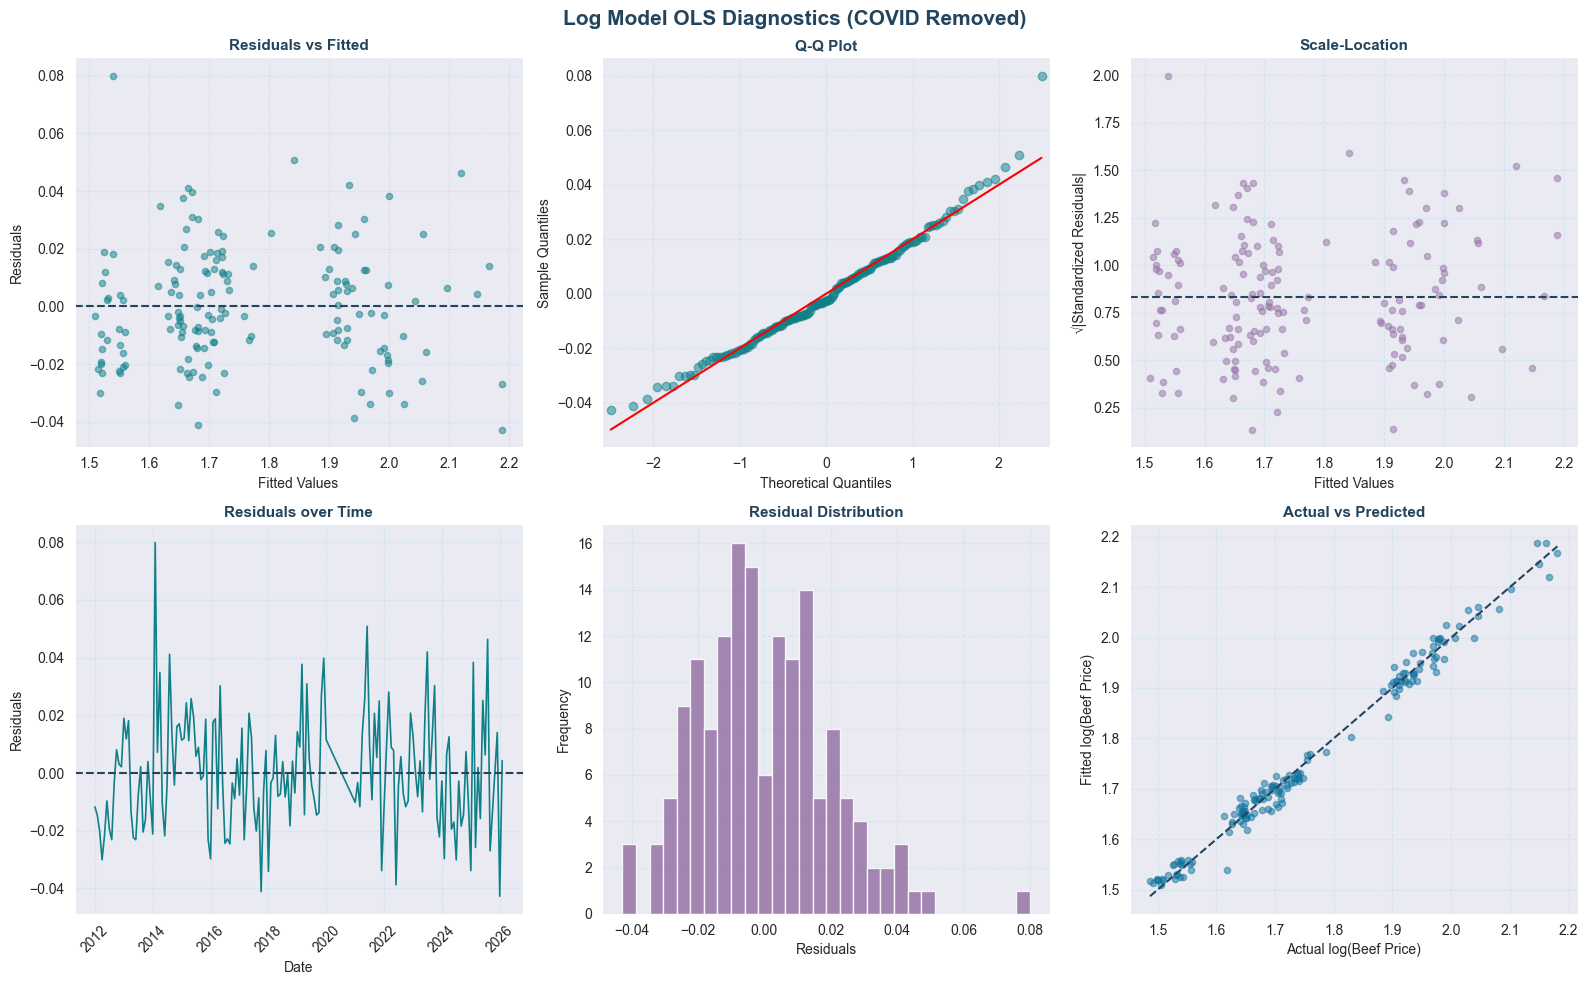


Durbin-Watson:  1.7870
Shapiro-Wilk:   W=0.9805, p=0.025221 → NOT normal
Breusch-Pagan:  stat=4.0608, p=0.540694 → Homoskedastic ✅


In [43]:
fitted    = model_no_covid.fittedvalues
residuals = model_no_covid.resid
std_resid = residuals / residuals.std()

# align dates and y values
n         = len(residuals)
dates     = df_no_covid["observation_date"].iloc[-n:].reset_index(drop=True)
y_aligned = df_no_covid["log_beef"].iloc[-n:].reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), facecolor="white")
fig.suptitle("Log Model OLS Diagnostics (COVID Removed)",
             fontsize=15, fontweight="bold", color="#23445d")

# ── 1. Residuals vs Fitted ────────────────────────────────────────────────────
axes[0,0].scatter(fitted, residuals, color="#0e8088", alpha=0.5, s=20)
axes[0,0].axhline(0, color="#23445d", linestyle="--", linewidth=1.5)
axes[0,0].set_xlabel("Fitted Values", fontsize=10)
axes[0,0].set_ylabel("Residuals", fontsize=10)
axes[0,0].set_title("Residuals vs Fitted", fontsize=11, fontweight="bold", color="#23445d")
axes[0,0].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,0].spines[["top","right"]].set_visible(False)

# ── 2. Q-Q Plot ───────────────────────────────────────────────────────────────
qqplot(residuals, line="s", ax=axes[0,1], markerfacecolor="#0e8088",
       markeredgecolor="#0e8088", alpha=0.5)
axes[0,1].set_title("Q-Q Plot", fontsize=11, fontweight="bold", color="#23445d")
axes[0,1].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,1].spines[["top","right"]].set_visible(False)

# ── 3. Scale-Location ─────────────────────────────────────────────────────────
axes[0,2].scatter(fitted, np.sqrt(np.abs(std_resid)), color="#9673a6", alpha=0.5, s=20)
axes[0,2].axhline(np.sqrt(np.abs(std_resid)).mean(), color="#23445d", linestyle="--", linewidth=1.5)
axes[0,2].set_xlabel("Fitted Values", fontsize=10)
axes[0,2].set_ylabel("√|Standardized Residuals|", fontsize=10)
axes[0,2].set_title("Scale-Location", fontsize=11, fontweight="bold", color="#23445d")
axes[0,2].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[0,2].spines[["top","right"]].set_visible(False)

# ── 4. Residuals over time ────────────────────────────────────────────────────
axes[1,0].plot(dates, residuals.values, color="#0e8088", linewidth=1.2)
axes[1,0].axhline(0, color="#23445d", linestyle="--", linewidth=1.5)
axes[1,0].set_xlabel("Date", fontsize=10)
axes[1,0].set_ylabel("Residuals", fontsize=10)
axes[1,0].set_title("Residuals over Time", fontsize=11, fontweight="bold", color="#23445d")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,0].spines[["top","right"]].set_visible(False)

# ── 5. Residual histogram ─────────────────────────────────────────────────────
axes[1,1].hist(residuals, bins=30, color="#9673a6", edgecolor="white", alpha=0.85)
axes[1,1].set_xlabel("Residuals", fontsize=10)
axes[1,1].set_ylabel("Frequency", fontsize=10)
axes[1,1].set_title("Residual Distribution", fontsize=11, fontweight="bold", color="#23445d")
axes[1,1].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,1].spines[["top","right"]].set_visible(False)

# ── 6. Actual vs Predicted ────────────────────────────────────────────────────
axes[1,2].scatter(y_aligned, fitted, color="#10739e", alpha=0.5, s=20)
axes[1,2].plot([y_aligned.min(), y_aligned.max()],
               [y_aligned.min(), y_aligned.max()],
               color="#23445d", linestyle="--", linewidth=1.5)
axes[1,2].set_xlabel("Actual log(Beef Price)", fontsize=10)
axes[1,2].set_ylabel("Fitted log(Beef Price)", fontsize=10)
axes[1,2].set_title("Actual vs Predicted", fontsize=11, fontweight="bold", color="#23445d")
axes[1,2].grid(True, linestyle="--", alpha=0.4, color="#b1ddf0")
axes[1,2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nDurbin-Watson:  {durbin_watson(residuals):.4f}")
sw_stat, sw_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk:   W={sw_stat:.4f}, p={sw_p:.6f} → {'NOT normal' if sw_p < 0.05 else 'normal ✅'}")
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, model_no_covid.model.exog)
print(f"Breusch-Pagan:  stat={bp_stat:.4f}, p={bp_p:.6f} → {'Heteroskedasticity detected' if bp_p < 0.05 else 'Homoskedastic ✅'}")

# More Model Diagnostics

## Looking at VIF for the features in this model

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

features = ["beef_lag", "log_meat_index", "log_cattle_spread", "log_ulsd", "wpi"]

X_vif = df_no_covid[features].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = features
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(features))]

print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

          feature        VIF
   log_meat_index 413.512986
         beef_lag 346.604002
         log_ulsd  13.856223
log_cattle_spread   3.153595
              wpi   1.718023


This showed that there is still high VIF for log_meat_index and the beef_lag features indicating that there is def some collinearity going on there. I feel like this might just be expected since there is likely just some correlation between them.